# Fase 5 — Señales Base (Z-score) y Backtest Benchmark

**Objetivo**: implementar la estrategia clasica de pairs trading basada en bandas Z-score como **benchmark** que el LSTM+RL deberan superar.

**Reglas**:
- **entry_short** (apostar a que el spread baja): `spread_z > +2.0` → vender Oro, comprar β·Plata
- **entry_long** (apostar a que el spread sube): `spread_z < -2.0` → comprar Oro, vender β·Plata
- **exit**: `|spread_z| < 0.5`
- **stop loss**: `|spread_z| > 4.0`

**Costos**: 5 bps por trade (comision + slippage). Posicion ±1 (notional fijo, sin Kelly).

**Metricas**: equity curve, retorno anualizado, Sharpe, Sortino, Max Drawdown, # trades, win rate.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.backtest import backtest_pair_strategy, performance_metrics

DATA_DIR = Path('data')
df = pd.read_parquet(DATA_DIR / 'features.parquet')
print(f'Datos: {df.shape}, rango {df.index.min().date()} -> {df.index.max().date()}')
df[['spread_kalman','spread_z','Gold','Silver','beta_kalman']].head()


Datos: (1038, 20), rango 2022-03-30 -> 2026-05-15


,spread_kalman,spread_z,Gold,Silver,beta_kalman
Date,,,,,
2022-03-30,0.003457,0.327137,1933.500000,25.103001,1.785329
2022-03-31,0.007334,0.486930,1949.199951,25.121000,1.786158
2022-04-01,0.018751,0.951876,1919.099976,24.642000,1.788245
2022-04-04,0.020221,1.039539,1929.199951,24.584000,1.790502
2022-04-05,0.015074,0.818205,1922.900024,24.528000,1.792187


## 5.1 Construccion de señales discretas
`signal_t ∈ {-1, 0, +1}` representa la posicion deseada SOBRE EL SPREAD:
- +1: long spread (esperamos que suba)
- -1: short spread (esperamos que baje)
- 0: flat

Implementacion: cuando entramos al limite, mantenemos hasta exit/stop.


In [2]:
ENTRY_Z = 2.0
EXIT_Z  = 0.5
STOP_Z  = 4.0

def zscore_signals(z, entry=ENTRY_Z, exit_=EXIT_Z, stop=STOP_Z):
    pos = np.zeros(len(z))
    cur = 0
    for i, v in enumerate(z.values):
        if cur == 0:
            if v > entry:   cur = -1
            elif v < -entry: cur = +1
        else:
            if abs(v) < exit_ or abs(v) > stop:
                cur = 0
        pos[i] = cur
    return pd.Series(pos, index=z.index, name='signal')

df['signal'] = zscore_signals(df['spread_z'])
print(df['signal'].value_counts())
print(f'\n% del tiempo en posicion: {(df["signal"]!=0).mean()*100:.1f}%')


signal
 0.0    847
 1.0    100
-1.0     91
Name: count, dtype: int64

% del tiempo en posicion: 18.4%


## 5.2 PnL del spread
Tradear el spread = posicion en Oro − β · posicion en Plata. El PnL diario en log-units es:

$$\text{PnL}_t = \text{signal}_{t-1} \cdot (\Delta\ln P_{oro,t} - \beta_{t-1} \cdot \Delta\ln P_{plata,t})$$

**Importante**: usamos `signal.shift(1)` para evitar look-ahead (la decision se toma en t pero el retorno corresponde a t+1).


In [3]:
COST_BPS = 5

bt_bench = backtest_pair_strategy(
    df['signal'],
    df['Gold'],
    df['Silver'],
    df['beta_kalman'],
    cost_bps=COST_BPS,
    normalize_gross=True,
    charge_beta_rebalance=True,
)

df['pnl_gross'] = bt_bench.pnl_gross
df['costs'] = bt_bench.costs
df['pnl_net'] = bt_bench.pnl_net
df['equity'] = bt_bench.equity
df['turnover'] = bt_bench.turnover
df['gold_weight'] = bt_bench.gold_weight
df['silver_weight'] = bt_bench.silver_weight

n_signal_changes = int((df['signal'].diff().abs().fillna(df['signal'].abs()) > 0).sum())
print(f'N cambios de se?al: {n_signal_changes}')
print(f'Turnover bruto acumulado: {df["turnover"].sum():.2f}x capital')
print(f'Costos totales acumulados: {df["costs"].sum()*100:.2f}%')
print(f'Exposicion bruta promedio si esta activo: {(df.loc[df["signal"] != 0, "beta_kalman"].abs() + 1).mean():.2f}x')


N cambios de se?al: 77
Turnover bruto acumulado: 77.17x capital
Costos totales acumulados: 3.86%
Exposicion bruta promedio si esta activo: 2.69x


## 5.3 Metricas de performance

In [4]:
metrics_bench = performance_metrics(df['pnl_net'], df['equity'], name='Z-score Benchmark')
metrics_bench['Turnover'] = float(df['turnover'].sum())
metrics_bench['Total_Costs'] = float(df['costs'].sum())
for k, v in metrics_bench.items():
    print(f'  {k:20s}: {v:.4f}' if isinstance(v,float) else f'  {k:20s}: {v}')


  Strategy            : Z-score Benchmark
  N                   : 1038
  AnnReturn           : -0.0025
  AnnVol              : 0.0781
  Sharpe              : 0.0070
  Sortino             : 0.0046
  MaxDD               : -0.1311
  Calmar              : -0.0190
  WinRate(active)     : 0.3755
  FinalEquity         : 0.9898
  Turnover            : 77.1668
  Total_Costs         : 0.0386


## 5.4 Equity curve y drawdown

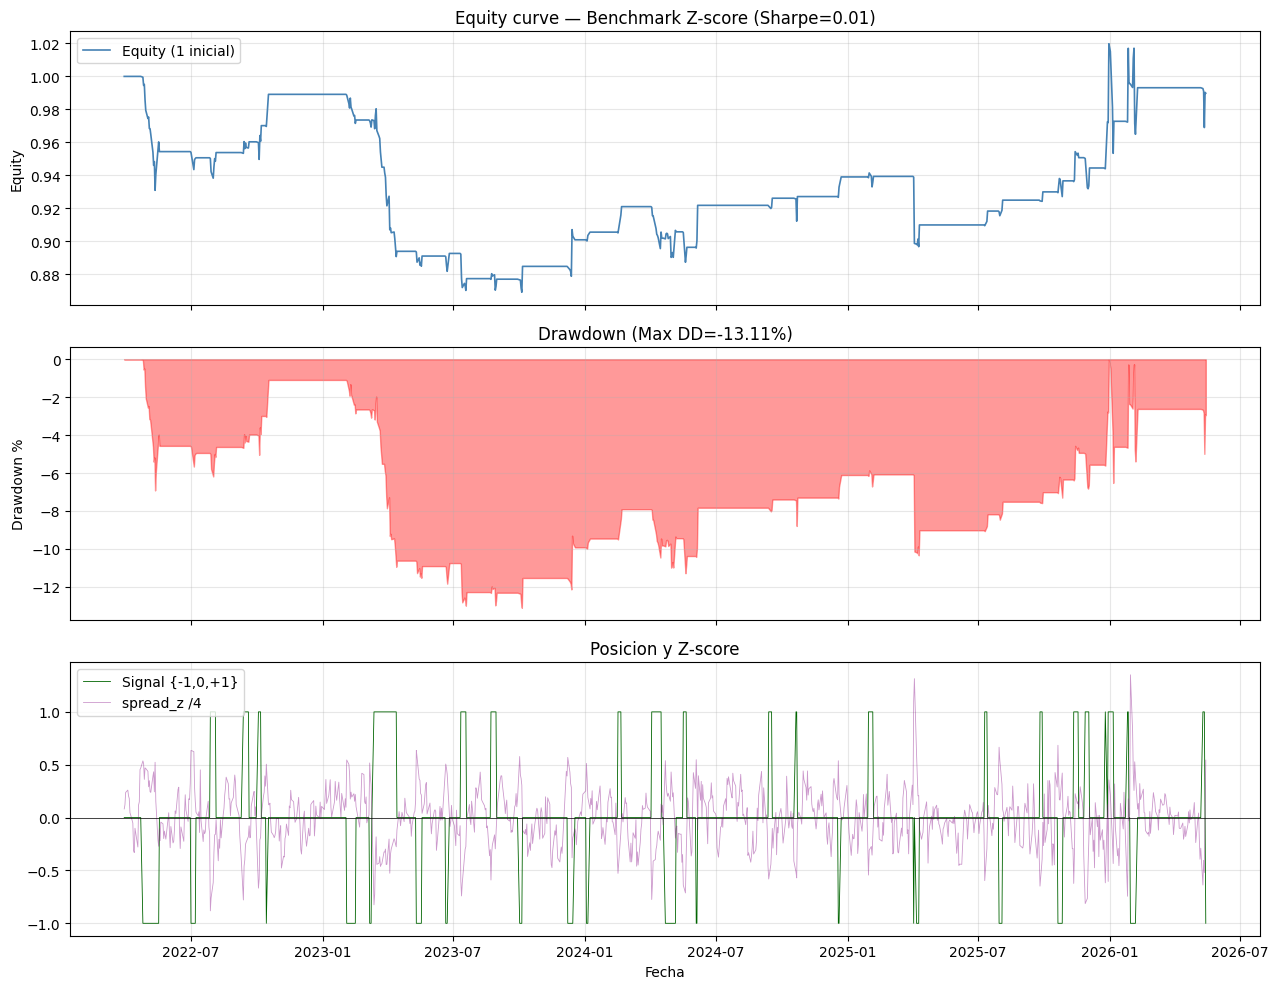

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

ax = axes[0]
ax.plot(df.index, df['equity'], color='steelblue', lw=1.2, label='Equity (1 inicial)')
ax.set_title(f'Equity curve — Benchmark Z-score (Sharpe={metrics_bench["Sharpe"]:.2f})')
ax.set_ylabel('Equity'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
roll_max = df['equity'].cummax()
dd = (df['equity']/roll_max - 1) * 100
ax.fill_between(df.index, dd, 0, color='red', alpha=0.4)
ax.set_title(f'Drawdown (Max DD={metrics_bench["MaxDD"]*100:.2f}%)')
ax.set_ylabel('Drawdown %'); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(df.index, df['signal'], color='darkgreen', lw=0.6, label='Signal {-1,0,+1}')
ax.plot(df.index, df['spread_z']/4, color='purple', lw=0.6, alpha=0.4, label='spread_z /4')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Posicion y Z-score'); ax.set_xlabel('Fecha'); ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout(); fig.savefig(DATA_DIR / 'benchmark_zscore.png', dpi=120)
plt.show()


## 5.5 Persistencia de señales y benchmark

In [6]:
signals_out = df[[
    'spread_kalman', 'spread_z', 'beta_kalman', 'signal',
    'gold_weight', 'silver_weight', 'turnover', 'costs', 'pnl_net', 'equity'
]].copy()
signals_out.to_csv(DATA_DIR / 'signals_benchmark.csv')
pd.Series(metrics_bench).to_json(DATA_DIR / 'metrics_benchmark.json')
print(f'Guardado: data/signals_benchmark.csv y data/metrics_benchmark.json')
print(f'\nSharpe benchmark corregido a superar: {metrics_bench["Sharpe"]:.3f}')


Guardado: data/signals_benchmark.csv y data/metrics_benchmark.json

Sharpe benchmark corregido a superar: 0.007


## Conclusion Fase 5

Tenemos un **benchmark cuantificado** con la estrategia Z-score clasica. Esta es la barra que el LSTM y el agente RL **deben superar**. Si las metodologias mas sofisticadas no mejoran el Sharpe del benchmark, no agregan valor.

Si el Sharpe del benchmark ya es ≥ 1.5, eso ya cumple el objetivo del proyecto y el ML/RL es **mejora marginal**. Si es bajo o negativo, el ML tiene mucho margen para añadir valor.
